# K-Means Customer Clustering

Two **separate** models - one for electricity, one for gas.

## Methodology

1. Select k via silhouette score, **never using the known archetype labels**.
2. Fit the final model.
3. Validate against the known generating archetype.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../src")
import clustering as cl
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

OUTPUTS_DIR = Path("../data/outputs")
GENERATED_DIR = Path("../data/inputs/generated")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

electricity_features = pd.read_csv(OUTPUTS_DIR / "electricity_features.csv")
gas_features = pd.read_csv(OUTPUTS_DIR / "gas_features.csv")
metadata = pd.read_csv(GENERATED_DIR / "synthetic_metadata.csv")

elec_cols = cl.feature_columns(electricity_features)
gas_cols = cl.feature_columns(gas_features)

electricity_data = electricity_features.merge(
    metadata[["customer_id", "electricity_archetype"]], on="customer_id",
)
gas_data = gas_features.merge(
    metadata[["customer_id", "gas_archetype"]], on="customer_id",
)

print(f"Electricity: {len(electricity_data)} customers")
print(f"Gas: {len(gas_data)} customers")


Electricity: 250 customers
Gas: 158 customers


## 1. Select k


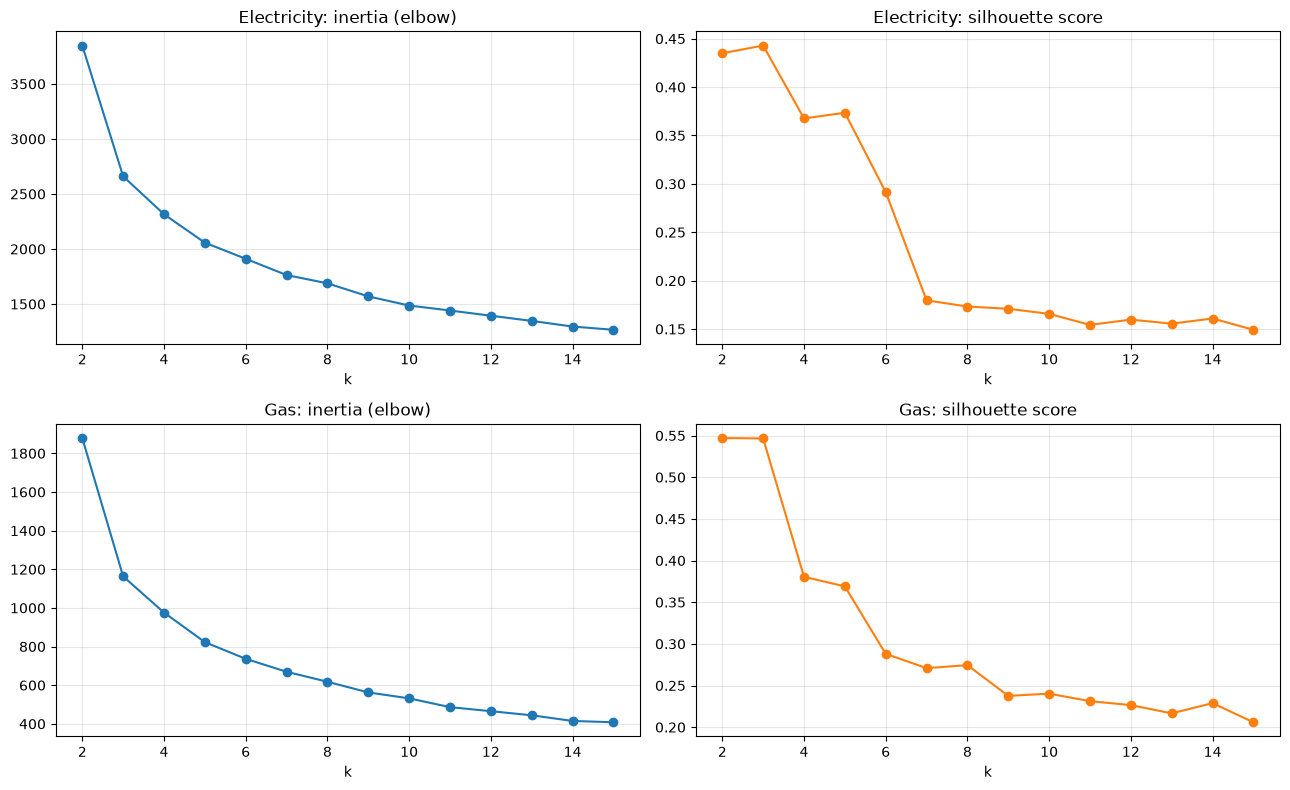

Chosen k - electricity: 3 (silhouette 0.443)
Chosen k - gas: 2 (silhouette 0.547)


In [2]:
elec_k_eval = cl.evaluate_k_range(electricity_data, elec_cols, k_range=range(2, 16))
gas_k_eval = cl.evaluate_k_range(gas_data, gas_cols, k_range=range(2, 16))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax_row, (name, k_eval) in zip(axes, [("Electricity", elec_k_eval), ("Gas", gas_k_eval)]):
    ax_row[0].plot(k_eval["k"], k_eval["inertia"], marker="o")
    ax_row[0].set_title(f"{name}: inertia (elbow)")
    ax_row[0].set_xlabel("k")
    ax_row[0].grid(alpha=0.3)

    ax_row[1].plot(k_eval["k"], k_eval["silhouette_score"], marker="o", color="tab:orange")
    ax_row[1].set_title(f"{name}: silhouette score")
    ax_row[1].set_xlabel("k")
    ax_row[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

K_ELECTRICITY = int(elec_k_eval.loc[elec_k_eval["silhouette_score"].idxmax(), "k"])
K_GAS = int(gas_k_eval.loc[gas_k_eval["silhouette_score"].idxmax(), "k"])
print(f"Chosen k - electricity: {K_ELECTRICITY} (silhouette {elec_k_eval['silhouette_score'].max():.3f})")
print(f"Chosen k - gas: {K_GAS} (silhouette {gas_k_eval['silhouette_score'].max():.3f})")


## 2. Fit the final models

In [3]:
electricity_pipeline, elec_labels = cl.build_and_fit(electricity_data, elec_cols, n_clusters=K_ELECTRICITY)
gas_pipeline, gas_labels = cl.build_and_fit(gas_data, gas_cols, n_clusters=K_GAS)

electricity_data["cluster"] = elec_labels
gas_data["cluster"] = gas_labels

print("Electricity clusters fitted:", electricity_data["cluster"].nunique())
print("Gas clusters fitted:", gas_data["cluster"].nunique())


Electricity clusters fitted: 3
Gas clusters fitted: 2


## 3. Validate against known archetypes

Adjusted Rand Index: 1.0 = perfect agreement with the known generating archetype, 0.0 = random.

In [4]:
elec_ari = adjusted_rand_score(electricity_data["electricity_archetype"], electricity_data["cluster"])
print(f"Electricity ARI vs known archetype: {elec_ari:.3f}")
display(pd.crosstab(electricity_data["cluster"], electricity_data["electricity_archetype"]))


Electricity ARI vs known archetype: 0.489


electricity_archetype,flexible_peaky,industrial,intensive_industrial,medium_commercial,small_commercial
cluster,,,,,
0,25,0,0,77,50
1,0,0,18,0,0
2,0,72,8,0,0


In [5]:
gas_ari = adjusted_rand_score(gas_data["gas_archetype"], gas_data["cluster"])
print(f"Gas ARI vs known archetype: {gas_ari:.3f}")
display(pd.crosstab(gas_data["cluster"], gas_data["gas_archetype"]))


Gas ARI vs known archetype: 1.000


gas_archetype,heating_gas,process_gas
cluster,,
0,0,73
1,85,0


## 4. Visualize (PCA projection)

2D projection of the same imputed/scaled features the model actually clusters on, colored by cluster.

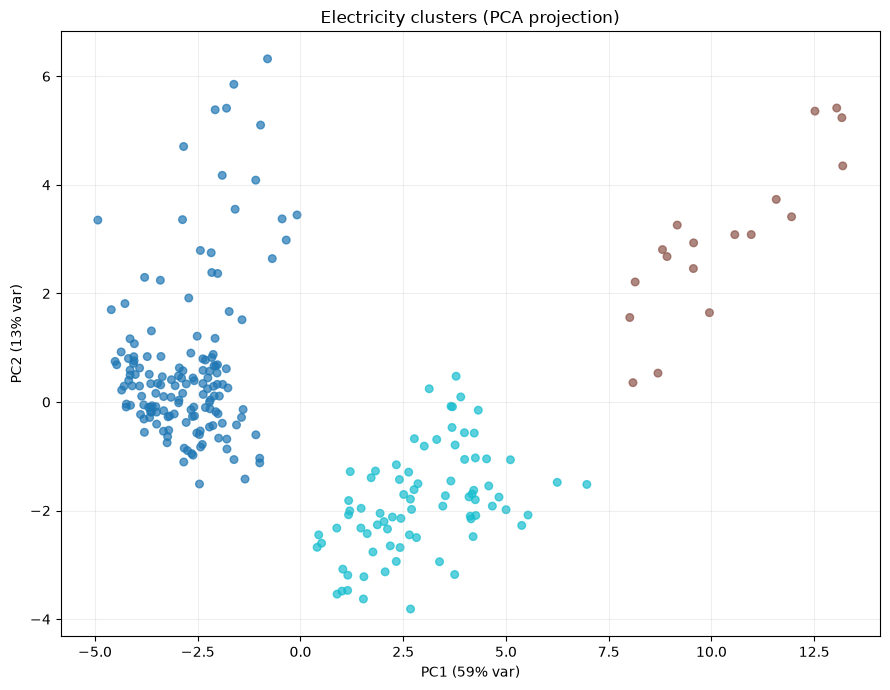

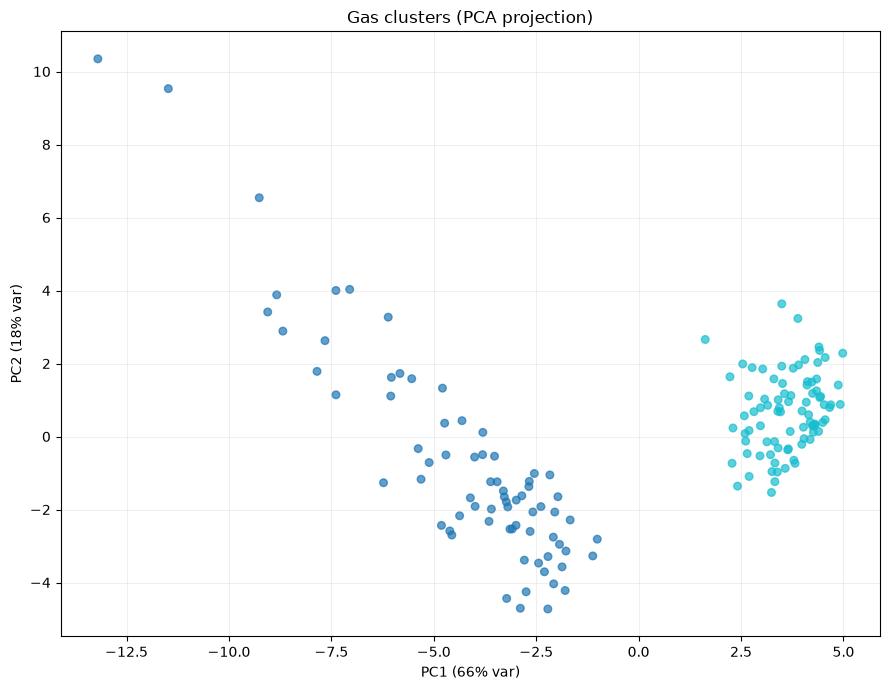

In [6]:
def plot_clusters_pca(df, feature_cols, pipeline, title):
    imputer = pipeline.named_steps["imputer"]
    scaler = pipeline.named_steps["scaler"]
    X = scaler.transform(imputer.transform(df[feature_cols].to_numpy(dtype=float)))

    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(9, 7))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"], cmap="tab10", alpha=0.7, s=30)
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


plot_clusters_pca(electricity_data, elec_cols, electricity_pipeline, "Electricity clusters (PCA projection)")
plot_clusters_pca(gas_data, gas_cols, gas_pipeline, "Gas clusters (PCA projection)")


## 5. Save models and cluster assignments

In [7]:
joblib.dump(electricity_pipeline, MODELS_DIR / "kmeans_pipeline_electricity.joblib")
joblib.dump(gas_pipeline, MODELS_DIR / "kmeans_pipeline_gas.joblib")

electricity_data[["customer_id", "electricity_archetype", "cluster"]].to_csv(
    OUTPUTS_DIR / "electricity_clusters.csv", index=False
)
gas_data[["customer_id", "gas_archetype", "cluster"]].to_csv(
    OUTPUTS_DIR / "gas_clusters.csv", index=False
)

print("Saved:")
print(" ", MODELS_DIR / "kmeans_pipeline_electricity.joblib")
print(" ", MODELS_DIR / "kmeans_pipeline_gas.joblib")
print(" ", OUTPUTS_DIR / "electricity_clusters.csv")
print(" ", OUTPUTS_DIR / "gas_clusters.csv")


Saved:
  ..\models\kmeans_pipeline_electricity.joblib
  ..\models\kmeans_pipeline_gas.joblib
  ..\data\outputs\electricity_clusters.csv
  ..\data\outputs\gas_clusters.csv
